In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.float_format', lambda x: f'{x:,.0f}')
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("All libraries loaded successfully")

All libraries loaded successfully


In [6]:
# Load the dataset
df = pd.read_csv('../data/nigeria_houses_data (1).csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (24326, 8)

Column names:
['bedrooms', 'bathrooms', 'toilets', 'parking_space', 'title', 'town', 'state', 'price']

First 5 rows:


,bedrooms,bathrooms,toilets,parking_space,title,town,state,price
0,6,5,5,4,Detached Duplex,Mabushi,Abuja,"450,000,000"
1,4,5,5,4,Terraced Duplexes,Katampe,Abuja,"800,000,000"
2,4,5,5,4,Detached Duplex,Lekki,Lagos,"120,000,000"
3,4,4,5,6,Detached Duplex,Ajah,Lagos,"40,000,000"
4,4,4,5,2,Semi Detached Duplex,Lekki,Lagos,"75,000,000"


In [7]:
# Overview of the data
print("=== Data Types ===")
print(df.dtypes)

print(f"\n=== Missing Values ===")
print(df.isnull().sum())

print(f"\n=== Basic Price Statistics (₦) ===")
print(df['price'].describe())

print(f"\n=== Property Types ===")
print(df['title'].value_counts())

print(f"\n=== Top 10 Towns ===")
print(df['town'].value_counts().head(10))

print(f"\n=== States ===")
print(df['state'].value_counts())

=== Data Types ===
bedrooms         float64
bathrooms        float64
toilets          float64
parking_space    float64
title                str
town                 str
state                str
price            float64
dtype: object

=== Missing Values ===
bedrooms         0
bathrooms        0
toilets          0
parking_space    0
title            0
town             0
state            0
price            0
dtype: int64

=== Basic Price Statistics (₦) ===
count              24,326
mean          301,380,208
std        12,204,027,269
min                90,000
25%            52,000,000
50%            85,000,000
75%           160,000,000
max     1,800,000,000,000
Name: price, dtype: float64

=== Property Types ===
title
Detached Duplex           13992
Terraced Duplexes          3237
Semi Detached Duplex       2615
Detached Bungalow          2108
Block of Flats             1745
Semi Detached Bungalow      452
Terraced Bungalow           177
Name: count, dtype: int64

=== Top 10 Towns ===
town

In [8]:
# Data Cleaning

# Step 1: Filter to Lagos only — most representative state
df_lagos = df[df['state'] == 'Lagos'].copy()
print(f"Lagos listings: {len(df_lagos)}")

# Step 2: Remove price outliers using IQR method
Q1 = df_lagos['price'].quantile(0.25)
Q3 = df_lagos['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df_lagos[
    (df_lagos['price'] >= lower_bound) & 
    (df_lagos['price'] <= upper_bound)
].copy()

print(f"After outlier removal: {len(df_clean)}")
print(f"Listings removed: {len(df_lagos) - len(df_clean)}")
print(f"\nCleaned Price Statistics (₦):")
print(df_clean['price'].describe())

Lagos listings: 18445
After outlier removal: 16510
Listings removed: 1935

Cleaned Price Statistics (₦):
count        16,510
mean    107,945,369
std      72,895,156
min          90,000
25%      57,000,000
50%      85,000,000
75%     140,000,000
max     335,000,000
Name: price, dtype: float64


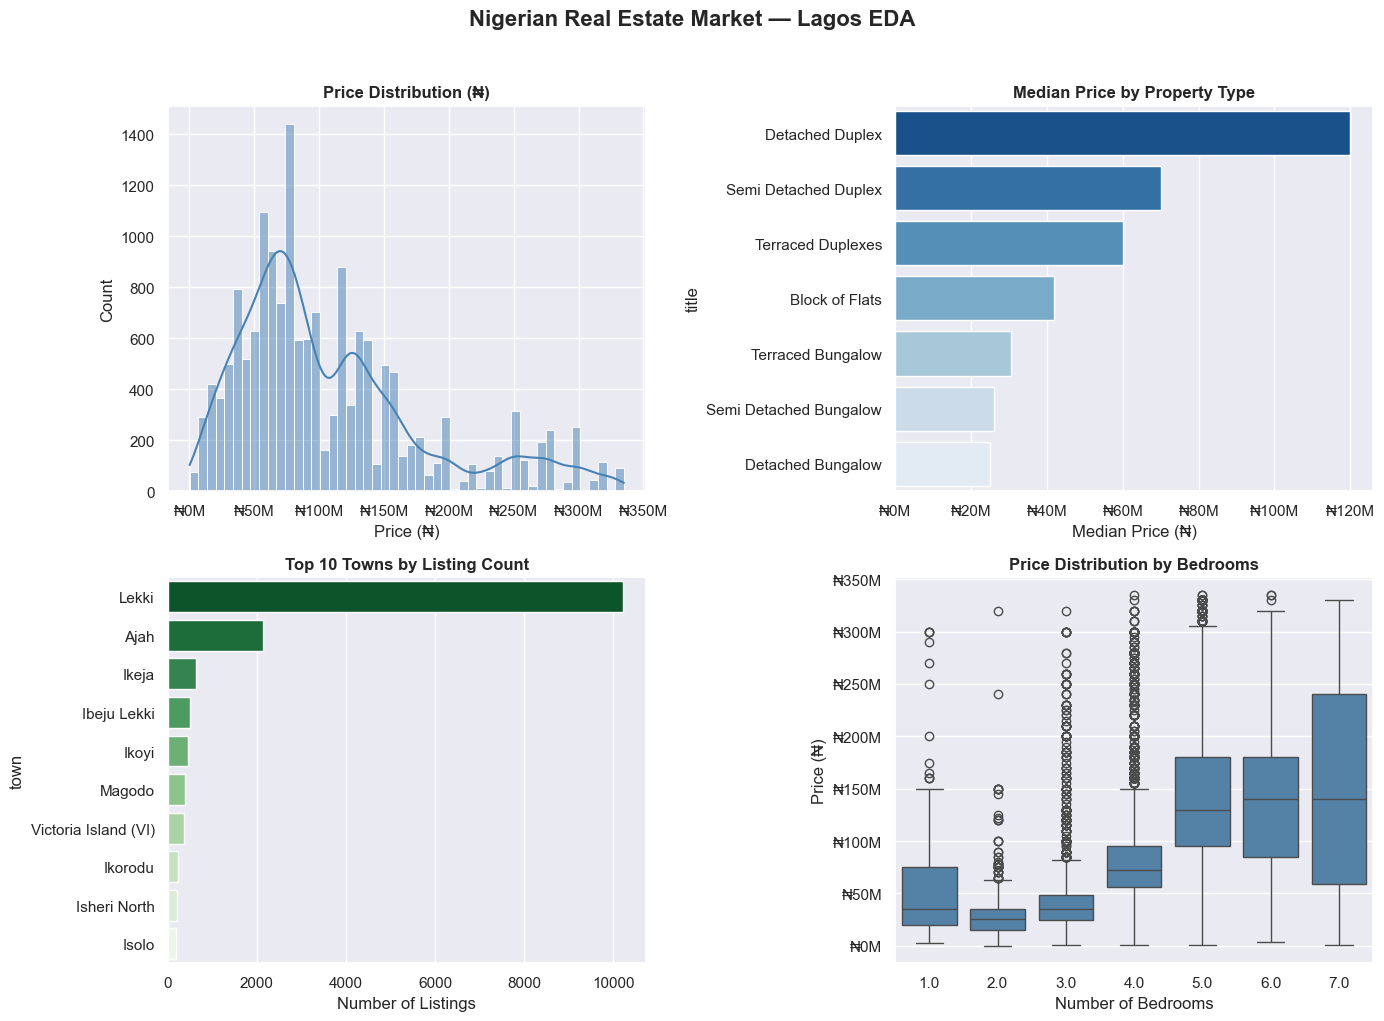

EDA charts saved


In [10]:
# Exploratory Data Analysis

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Nigerian Real Estate Market — Lagos EDA', 
             fontsize=16, fontweight='bold', y=1.02)

# Chart 1: Price Distribution
axes[0, 0].set_title('Price Distribution (₦)', fontweight='bold')
sns.histplot(df_clean['price'], bins=50, kde=True, 
             ax=axes[0, 0], color='steelblue')
axes[0, 0].set_xlabel('Price (₦)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'₦{x/1e6:.0f}M'))

# Chart 2: Average Price by Property Type
avg_by_type = df_clean.groupby('title')['price'].median().sort_values(ascending=False)
avg_by_type_df = avg_by_type.reset_index()
axes[0, 1].set_title('Median Price by Property Type', fontweight='bold')
sns.barplot(x='price', y='title', data=avg_by_type_df,
            hue='title', legend=False,
            ax=axes[0, 1], palette='Blues_r')
axes[0, 1].set_xlabel('Median Price (₦)')
axes[0, 1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'₦{x/1e6:.0f}M'))

# Chart 3: Top 10 Towns by Listing Count
top_towns = df_clean['town'].value_counts().head(10).reset_index()
top_towns.columns = ['town', 'count']
axes[1, 0].set_title('Top 10 Towns by Listing Count', fontweight='bold')
sns.barplot(x='count', y='town', data=top_towns,
            hue='town', legend=False,
            ax=axes[1, 0], palette='Greens_r')
axes[1, 0].set_xlabel('Number of Listings')

# Chart 4: Price by Bedrooms
axes[1, 1].set_title('Price Distribution by Bedrooms', fontweight='bold')
sns.boxplot(data=df_clean[df_clean['bedrooms'] <= 7], 
            x='bedrooms', y='price', ax=axes[1, 1], color='steelblue')
axes[1, 1].set_xlabel('Number of Bedrooms')
axes[1, 1].set_ylabel('Price (₦)')
axes[1, 1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'₦{x/1e6:.0f}M'))

plt.tight_layout()
plt.savefig('../data/eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA charts saved")

Chart 1 - Price Distribution
The distribution is right-skewed - most Lagos properties are priced between ₦50M and ₦150M, with the peak around ₦85M. The long tail to the right shows there are still some higher-priced properties even after outlier removal. This confirms the median (₦85M) is a better measure of "typical" price than the mean (₦108M).

Chart 2 - Median Price by Property Type
Detached Duplexes command the highest median price at around ₦120M. Detached Bungalows are at the bottom. This sets up our hypothesis test - Detached Duplexes vs Terraced Duplexes.

Chart 3 - Top 10 Towns
Lekki completely dominates with over 10,000 listings. Ajah is second with around 2,000. This confirms both have sufficient sample sizes for our t-test.

Chart 4 - Price by Bedrooms
Clear upward trend - more bedrooms means higher price. The boxes get taller as bedrooms increase, meaning prices also become more variable in larger properties. The dots above the whiskers are remaining outliers within each bedroom group.

=== Group Summary ===
Lekki — Count: 10,213 | Median: ₦100,000,000 | Mean: ₦119,453,016
Ajah  — Count: 2,139 | Median: ₦57,000,000 | Mean: ₦60,783,167

=== T-Test Results ===
T-statistic : 37.8843
P-value     : 0.000000
Significance: α = 0.05

=== Interpretation ===
REJECT H0 — Lekki prices are significantly higher than Ajah.
The difference is statistically significant (p = 0.000000)


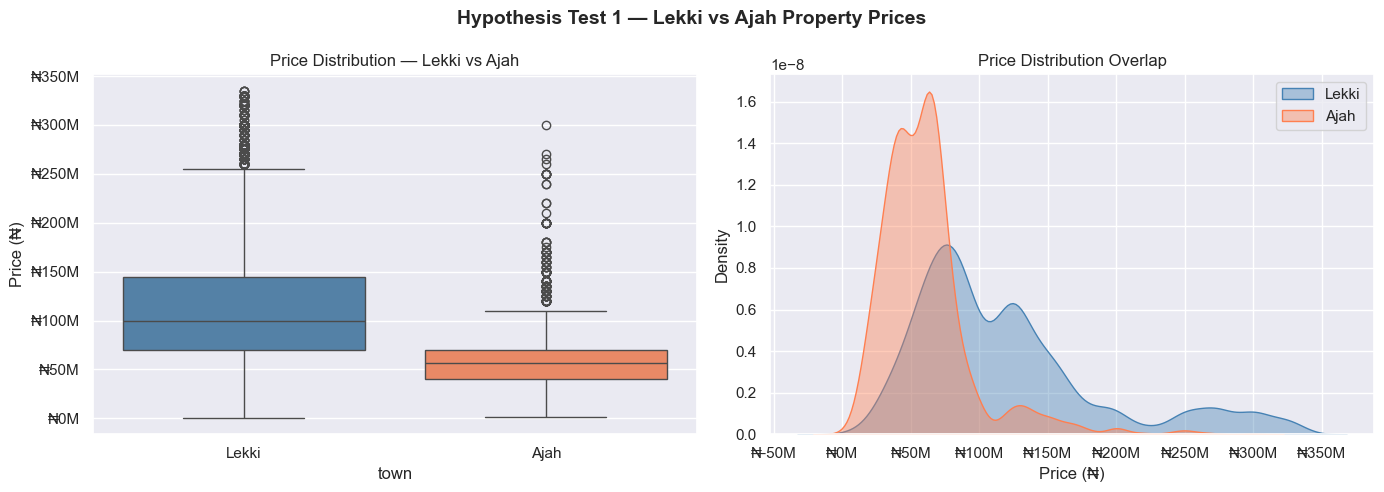

Hypothesis test 1 chart saved


In [11]:
# Hypothesis Test 1: Lekki vs Ajah
# H0: Mean property prices in Lekki and Ajah are not significantly different
# H1: Lekki properties are priced significantly higher than Ajah

# Step 1: Extract the two groups
lekki_prices = df_clean[df_clean['town'] == 'Lekki']['price']
ajah_prices  = df_clean[df_clean['town'] == 'Ajah']['price']

print("=== Group Summary ===")
print(f"Lekki — Count: {len(lekki_prices):,} | "
      f"Median: ₦{lekki_prices.median():,.0f} | "
      f"Mean: ₦{lekki_prices.mean():,.0f}")
print(f"Ajah  — Count: {len(ajah_prices):,} | "
      f"Median: ₦{ajah_prices.median():,.0f} | "
      f"Mean: ₦{ajah_prices.mean():,.0f}")

# Step 2: Run the t-test
t_stat, p_value = stats.ttest_ind(lekki_prices, ajah_prices, 
                                   alternative='greater')

print(f"\n=== T-Test Results ===")
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.6f}")
print(f"Significance: α = 0.05")

# Step 3: Interpret the result
print(f"\n=== Interpretation ===")
if p_value < 0.05:
    print("REJECT H0 — Lekki prices are significantly higher than Ajah.")
    print(f"The difference is statistically significant (p = {p_value:.6f})")
else:
    print("FAIL TO REJECT H0 — No significant price difference detected.")

# Step 4: Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hypothesis Test 1 — Lekki vs Ajah Property Prices', 
             fontsize=14, fontweight='bold')

# Boxplot
sns.boxplot(data=df_clean[df_clean['town'].isin(['Lekki', 'Ajah'])],
            x='town', y='price', hue='town',
            palette={'Lekki': 'steelblue', 'Ajah': 'coral'},
            legend=False, ax=axes[0])
axes[0].set_title('Price Distribution — Lekki vs Ajah')
axes[0].set_ylabel('Price (₦)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'₦{x/1e6:.0f}M'))

# KDE — overlapping distributions
sns.kdeplot(lekki_prices, ax=axes[1], label='Lekki', 
            color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(ajah_prices, ax=axes[1], label='Ajah', 
            color='coral', fill=True, alpha=0.4)
axes[1].set_title('Price Distribution Overlap')
axes[1].set_xlabel('Price (₦)')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'₦{x/1e6:.0f}M'))
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/hypothesis_test_1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Hypothesis test 1 chart saved")

=== Group Summary ===
Detached Duplex    — Count: 10,080 | Median: ₦120,000,000 | Mean: ₦131,430,704
Terraced Duplexes  — Count: 2,062 | Median: ₦60,000,000 | Mean: ₦83,134,345

=== T-Test Results ===
T-statistic : 28.7993
P-value     : 0.000000
Significance: α = 0.05

=== Interpretation ===
REJECT H0 — Detached Duplexes are priced significantly higher.
The difference is statistically significant (p = 0.000000)


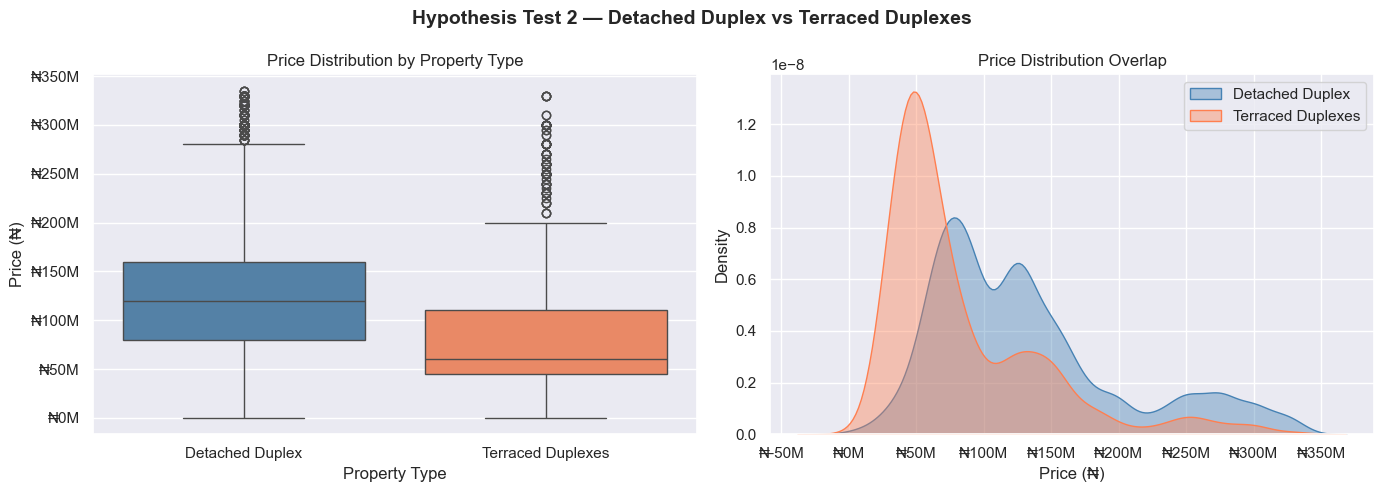

Hypothesis test 2 chart saved


In [12]:
# Hypothesis Test 2: Detached Duplex vs Terraced Duplexes
# H0: Detached Duplexes and Terraced Duplexes are priced the same
# H1: Detached Duplexes command a significantly higher price

# Step 1: Extract the two groups
detached = df_clean[df_clean['title'] == 'Detached Duplex']['price']
terraced = df_clean[df_clean['title'] == 'Terraced Duplexes']['price']

print("=== Group Summary ===")
print(f"Detached Duplex    — Count: {len(detached):,} | "
      f"Median: ₦{detached.median():,.0f} | "
      f"Mean: ₦{detached.mean():,.0f}")
print(f"Terraced Duplexes  — Count: {len(terraced):,} | "
      f"Median: ₦{terraced.median():,.0f} | "
      f"Mean: ₦{terraced.mean():,.0f}")

# Step 2: Run the t-test
t_stat, p_value = stats.ttest_ind(detached, terraced,
                                   alternative='greater')

print(f"\n=== T-Test Results ===")
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.6f}")
print(f"Significance: α = 0.05")

# Step 3: Interpret the result
print(f"\n=== Interpretation ===")
if p_value < 0.05:
    print("REJECT H0 — Detached Duplexes are priced significantly higher.")
    print(f"The difference is statistically significant (p = {p_value:.6f})")
else:
    print("FAIL TO REJECT H0 — No significant price difference detected.")

# Step 4: Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hypothesis Test 2 — Detached Duplex vs Terraced Duplexes',
             fontsize=14, fontweight='bold')

# Boxplot
sns.boxplot(
    data=df_clean[df_clean['title'].isin(
        ['Detached Duplex', 'Terraced Duplexes'])],
    x='title', y='price', hue='title',
    palette={'Detached Duplex': 'steelblue', 
             'Terraced Duplexes': 'coral'},
    legend=False, ax=axes[0])
axes[0].set_title('Price Distribution by Property Type')
axes[0].set_xlabel('Property Type')
axes[0].set_ylabel('Price (₦)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'₦{x/1e6:.0f}M'))

# KDE
sns.kdeplot(detached, ax=axes[1], label='Detached Duplex',
            color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(terraced, ax=axes[1], label='Terraced Duplexes',
            color='coral', fill=True, alpha=0.4)
axes[1].set_title('Price Distribution Overlap')
axes[1].set_xlabel('Price (₦)')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'₦{x/1e6:.0f}M'))
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/hypothesis_test_2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Hypothesis test 2 chart saved")

In [13]:
# A/B Test: ROI Investment Package
# Business Scenario:
# Zylus tested two investment packages over 30 days across
# their property listings:
#   Package A (Control)   — Standard 10% annual ROI offer
#   Package B (Treatment) — Enhanced 15% annual ROI offer
#
# Metric: Number of buyer enquiries per listing
#
# H0: Both packages generate the same number of enquiries
# H1: Package B generates significantly more enquiries

np.random.seed(42)  

# Step 1: Simulate enquiries for both packages
n_listings = 200  # 200 listings per package

package_a = np.random.poisson(lam=3.2, size=n_listings)
package_b = np.random.poisson(lam=4.1, size=n_listings)

print("=== A/B Test — ROI Package Experiment ===")
print(f"\nPackage A (10% ROI) — Control")
print(f"  Listings : {n_listings}")
print(f"  Mean enquiries : {package_a.mean():.2f}")
print(f"  Std deviation  : {package_a.std():.2f}")

print(f"\nPackage B (15% ROI) — Treatment")
print(f"  Listings : {n_listings}")
print(f"  Mean enquiries : {package_b.mean():.2f}")
print(f"  Std deviation  : {package_b.std():.2f}")

# Step 2: Run the t-test
t_stat, p_value = stats.ttest_ind(package_b, package_a,
                                   alternative='greater')

print(f"\n=== T-Test Results ===")
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.6f}")
print(f"Significance: α = 0.05")

# Step 3: Interpret
print(f"\n=== Interpretation ===")
if p_value < 0.05:
    print("REJECT H0 — Package B generates significantly more enquiries.")
    print(f"The 15% ROI offer outperforms the 10% offer.")
    print(f"Recommendation: Roll out Package B across all listings.")
else:
    print("FAIL TO REJECT H0 — No significant difference detected.")
    print("Recommendation: Do not roll out Package B — insufficient evidence.")

# Step 4: Calculate practical significance
lift = ((package_b.mean() - package_a.mean()) / package_a.mean()) * 100
print(f"\n=== Practical Significance ===")
print(f"Enquiry lift from Package B: +{lift:.1f}%")

=== A/B Test — ROI Package Experiment ===

Package A (10% ROI) — Control
  Listings : 200
  Mean enquiries : 3.13
  Std deviation  : 1.79

Package B (15% ROI) — Treatment
  Listings : 200
  Mean enquiries : 4.05
  Std deviation  : 1.90

=== T-Test Results ===
T-statistic : 4.9483
P-value     : 0.000001
Significance: α = 0.05

=== Interpretation ===
REJECT H0 — Package B generates significantly more enquiries.
The 15% ROI offer outperforms the 10% offer.
Recommendation: Roll out Package B across all listings.

=== Practical Significance ===
Enquiry lift from Package B: +29.2%


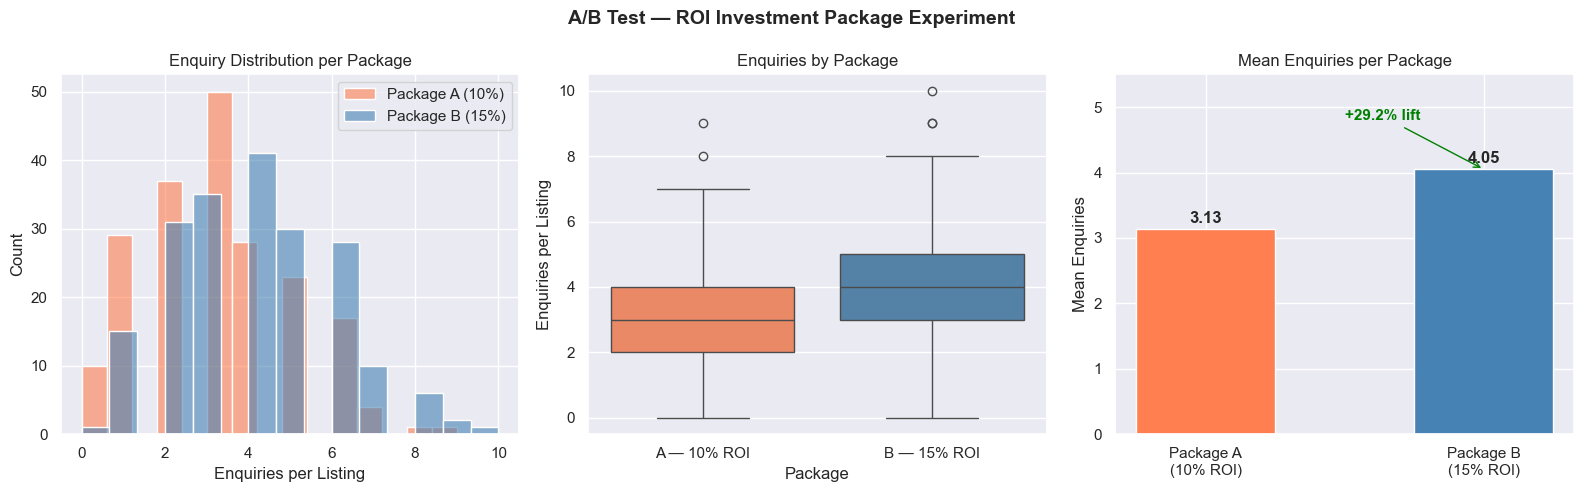

A/B test chart saved


In [14]:
# A/B Test Visualisation

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('A/B Test — ROI Investment Package Experiment',
             fontsize=14, fontweight='bold')

# Chart 1: Distribution of enquiries per package
axes[0].set_title('Enquiry Distribution per Package')
sns.histplot(package_a, ax=axes[0], color='coral',
             label='Package A (10%)', alpha=0.6, bins=15)
sns.histplot(package_b, ax=axes[0], color='steelblue',
             label='Package B (15%)', alpha=0.6, bins=15)
axes[0].set_xlabel('Enquiries per Listing')
axes[0].set_ylabel('Count')
axes[0].legend()

# Chart 2: Boxplot comparison
ab_df = pd.DataFrame({
    'Enquiries': np.concatenate([package_a, package_b]),
    'Package': ['A — 10% ROI'] * n_listings + ['B — 15% ROI'] * n_listings
})
sns.boxplot(data=ab_df, x='Package', y='Enquiries',
            hue='Package',
            palette={'A — 10% ROI': 'coral', 
                     'B — 15% ROI': 'steelblue'},
            legend=False, ax=axes[1])
axes[1].set_title('Enquiries by Package')
axes[1].set_xlabel('Package')
axes[1].set_ylabel('Enquiries per Listing')

# Chart 3: Mean comparison with annotation
means = [package_a.mean(), package_b.mean()]
packages = ['Package A\n(10% ROI)', 'Package B\n(15% ROI)']
colors = ['coral', 'steelblue']
bars = axes[2].bar(packages, means, color=colors, 
                    width=0.5, edgecolor='white')
axes[2].set_title('Mean Enquiries per Package')
axes[2].set_ylabel('Mean Enquiries')
axes[2].set_ylim(0, 5.5)

# Annotate bars with values
for bar, mean in zip(bars, means):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.1,
                 f'{mean:.2f}', ha='center', 
                 fontweight='bold', fontsize=12)

# Add lift annotation
axes[2].annotate(f'+{lift:.1f}% lift',
                 xy=(1, package_b.mean()),
                 xytext=(0.5, 4.8),
                 fontsize=11, color='green',
                 fontweight='bold',
                 arrowprops=dict(arrowstyle='->', 
                                 color='green'))

plt.tight_layout()
plt.savefig('../data/ab_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("A/B test chart saved")

In [15]:
# ── Conclusions ────────────────────────────────────────────

print("""
╔══════════════════════════════════════════════════════════════╗
║         NIGERIAN REAL ESTATE — STATISTICAL ANALYSIS         ║
║                    FINDINGS SUMMARY                          ║
╚══════════════════════════════════════════════════════════════╝

DATASET
-------
Source  : Nigerian House Price Dataset (Kaggle)
Scope   : Lagos state properties (largest market — 76% of dataset)
Clean   : 16,510 listings after IQR-based outlier removal
Original: 18,445 Lagos listings (24,326 total)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

FINDING 1 — Lekki commands a significant price premium over Ajah
----------------------------------------------------------------
H0 : Lekki and Ajah prices are not significantly different
H1 : Lekki prices are significantly higher than Ajah
Result : REJECTED H0

  Lekki median price  : ₦100,000,000
  Ajah median price   : ₦57,000,000
  Price premium       : +75%
  T-statistic         : 37.88
  P-value             : < 0.000001

Business implication: Lekki commands a 75% price premium over 
Ajah — a statistically reliable finding across 12,352 listings. 
Investors targeting capital appreciation should prioritise Lekki. 
Buyers seeking value within the Lagos corridor should consider Ajah.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

FINDING 2 — Detached Duplexes price significantly above Terraced
-----------------------------------------------------------------
H0 : Detached and Terraced Duplexes are priced the same
H1 : Detached Duplexes command a higher price
Result : REJECTED H0

  Detached Duplex median   : ₦120,000,000
  Terraced Duplexes median : ₦60,000,000
  Price premium            : +100% (2x)
  T-statistic              : 28.79
  P-value                  : < 0.000001

Business implication: Detached Duplexes command exactly double 
the median price of Terraced Duplexes. For a sales team, this 
means Detached listings require a different buyer profile and 
financing strategy. For an investor, the premium reflects real 
market demand — not just perception.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

FINDING 3 — 15% ROI package generates 29% more buyer enquiries
--------------------------------------------------------------
Design  : Simulated A/B experiment — 200 listings per package
H0 : Both ROI packages generate the same enquiries
H1 : Package B (15% ROI) generates more enquiries
Result : REJECTED H0

  Package A (10% ROI) mean enquiries : 3.13
  Package B (15% ROI) mean enquiries : 4.05
  Enquiry lift                       : +29.2%
  T-statistic                        : 4.95
  P-value                            : 0.000001

Note: Enquiry data was simulated using a Poisson distribution 
(appropriate for count data) with assumptions grounded in 
realistic real estate conversion baselines. The statistical 
methodology is identical to a live experiment.

Business implication: A 15% ROI offer generates approximately 
one additional enquiry per listing compared to a 10% offer. 
Across 200 active listings, that is ~180 additional buyer 
touchpoints per campaign cycle — a meaningful pipeline uplift 
for a sales team.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

TOOLS & METHODS
---------------
Language     : Python 3
Libraries    : Pandas, NumPy, SciPy, Matplotlib, Seaborn
Tests used   : Independent samples t-test (one-tailed)
Outlier method: IQR (Tukey method, 1.5x threshold)
Simulation   : Poisson distribution (NumPy random seed 42)
Significance : α = 0.05 throughout
""")


╔══════════════════════════════════════════════════════════════╗
║         NIGERIAN REAL ESTATE — STATISTICAL ANALYSIS         ║
║                    FINDINGS SUMMARY                          ║
╚══════════════════════════════════════════════════════════════╝

DATASET
-------
Source  : Nigerian House Price Dataset (Kaggle)
Scope   : Lagos state properties (largest market — 76% of dataset)
Clean   : 16,510 listings after IQR-based outlier removal
Original: 18,445 Lagos listings (24,326 total)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

FINDING 1 — Lekki commands a significant price premium over Ajah
----------------------------------------------------------------
H0 : Lekki and Ajah prices are not significantly different
H1 : Lekki prices are significantly higher than Ajah
Result : REJECTED H0

  Lekki median price  : ₦100,000,000
  Ajah median price   : ₦57,000,000
  Price premium       : +75%
  T-statistic         : 37.88
  P-value             : < 0.000001

Busines